# 05 — Tour of the 8 Analysis Types

A whirlwind tour. We submit all eight analyses in one batched
`run_area_and_wait` call, sharing the buildings / vegetation / weather
inputs across all of them.

| Analysis                       | Payload class                | Needs                                  |
|--------------------------------|------------------------------|----------------------------------------|
| Wind speed                     | `WindModelRequest`           | wind_speed, wind_direction             |
| Pedestrian wind comfort        | `PwcModelRequest`            | criteria, wind_speed[], wind_direction[] |
| Daylight availability          | `SolarModelRequest`          | location, time_period                  |
| Direct sun hours               | `SolarModelRequest`          | location, time_period                  |
| Sky view factors               | `SvfModelRequest`            | location                               |
| Solar radiation                | `SolarRadiationModelRequest` | location, time_period, weather         |
| Thermal comfort index (UTCI)   | `UtciModelRequest`           | location, time_period, weather         |
| Thermal comfort statistics (TCS)| `TcsModelRequest`           | location, time_period, weather, subtype |

In [1]:
from dotenv import load_dotenv
load_dotenv()

import logging, math
import numpy as np
import matplotlib.pyplot as plt

from infrared_sdk import InfraredClient
from infrared_sdk.analyses.types import (
    AnalysesName, BaseAnalysisPayload,
    PwcCriteria, PwcModelRequest,
    SolarModelRequest, SolarRadiationModelRequest, SvfModelRequest,
    TcsModelBaseRequest, TcsModelRequest, TcsSubtype,
    UtciModelBaseRequest, UtciModelRequest,
    WindModelRequest,
)
from infrared_sdk.models import Location, TimePeriod, extract_weather_fields
from cities import get

logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)-7s  %(message)s")
logging.getLogger("infrared_sdk").setLevel(logging.WARNING)

city = get("munich")
print(f"Running over: {city.name}")

Running over: Munich


## Pull layers and weather once

In [2]:
with InfraredClient() as client:
    area = client.buildings.get_area(city.polygon_small)
    veg  = client.vegetation.get_area(city.polygon_small)

    stations = client.weather.get_weather_file_from_location(
        lat=city.latitude, lon=city.longitude, radius=50,
    )
    weather_id = stations[0].get("identifier") or stations[0].get("uuid")

    tp = TimePeriod(start_month=6, start_day=1, start_hour=12,
                    end_month=8,   end_day=31, end_hour=17)
    weather = client.weather.filter_weather_data(identifier=weather_id, time_period=tp)

print(f"buildings={area.total_buildings}  trees={veg.total_trees}  weather_points={len(weather)}")

buildings=340  trees=119  weather_points=552


## Build payloads

We split into three groups by layer requirements (matches `demo_vienna.py`):

- **Group A** (buildings only): wind, sky view factors, pedestrian wind comfort.
- **Group B** (buildings + vegetation): daylight, direct sun hours, solar radiation.
- **Group C** (all layers): UTCI, TCS.

This isn't strictly necessary -- the SDK accepts any mix -- but it
mirrors the natural data dependencies and lets the orchestrator share
layer payloads between requests.

In [3]:
location = Location(latitude=city.latitude, longitude=city.longitude)
wind_fields = extract_weather_fields(weather, ["windSpeed", "windDirection"])

group_a = [
    WindModelRequest(analysis_type=AnalysesName.wind_speed,
                     wind_speed=5, wind_direction=270),
    SvfModelRequest(analysis_type=AnalysesName.sky_view_factors,
                    latitude=city.latitude, longitude=city.longitude),
    PwcModelRequest(analysis_type=AnalysesName.pedestrian_wind_comfort,
                    criteria=PwcCriteria.lawson_lddc, **wind_fields),
]

group_b = [
    SolarModelRequest(analysis_type=AnalysesName.daylight_availability,
                      latitude=city.latitude, longitude=city.longitude, time_period=tp),
    SolarModelRequest(analysis_type=AnalysesName.direct_sun_hours,
                      latitude=city.latitude, longitude=city.longitude, time_period=tp),
    SolarRadiationModelRequest.from_weatherfile_payload(
        payload=BaseAnalysisPayload(analysis_type=AnalysesName.solar_radiation),
        location=location, time_period=tp, weather_data=weather),
]

group_c = [
    UtciModelRequest.from_weatherfile_payload(
        payload=UtciModelBaseRequest(analysis_type=AnalysesName.thermal_comfort_index),
        location=location, time_period=tp, weather_data=weather),
    TcsModelRequest.from_weatherfile_payload(
        payload=TcsModelBaseRequest(
            analysis_type=AnalysesName.thermal_comfort_statistics,
            subtype=TcsSubtype.heat_stress),
        location=location, time_period=tp, weather_data=weather),
]
print(f"group_a={len(group_a)}  group_b={len(group_b)}  group_c={len(group_c)}")

group_a=3  group_b=3  group_c=2


## Submit all three groups

In [4]:
results: dict[str, "AreaResult"] = {}

with InfraredClient() as client:
    for label, payloads, kwargs in [
        ("A", group_a, dict(buildings=area.buildings, vegetation={}, ground_materials={})),
        ("B", group_b, dict(buildings=area.buildings, vegetation=veg.features, ground_materials={})),
        ("C", group_c, dict(buildings=area.buildings, vegetation=veg.features, ground_materials={})),
    ]:
        rs = client.run_area_and_wait(payloads, city.polygon_small, **kwargs)
        for r in rs:
            results[r.analysis_type] = r
        print(f"group {label}: {[r.analysis_type for r in rs]}")

group A: ['wind-speed', 'sky-view-factors', 'pedestrian-wind-comfort']


2026-04-28 16:39:49,332  WARNING  Failed to submit job for payload[0] tile fe2eff4e-57dd-5380-95da-2f9d0667c375: Failed to submit daylight-availability job: 400 - {"err": "Analysis supports only a single month, but time-period spans month 6 to 8"}


2026-04-28 16:39:50,239  WARNING  Failed to submit job for payload[1] tile fe2eff4e-57dd-5380-95da-2f9d0667c375: Failed to submit direct-sun-hours job: 400 - {"err": "Analysis supports only a single month, but time-period spans month 6 to 8"}


group B: ['daylight-availability', 'direct-sun-hours', 'solar-radiation']


group C: ['thermal-comfort-index', 'thermal-comfort-statistics']


## Render every result in one figure

C:\Users\User\AppData\Local\Temp\ipykernel_30692\3545392546.py:29: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(np.flipud(r.merged_grid), cmap=cmap,
C:\Users\User\AppData\Local\Temp\ipykernel_30692\3545392546.py:29: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(np.flipud(r.merged_grid), cmap=cmap,


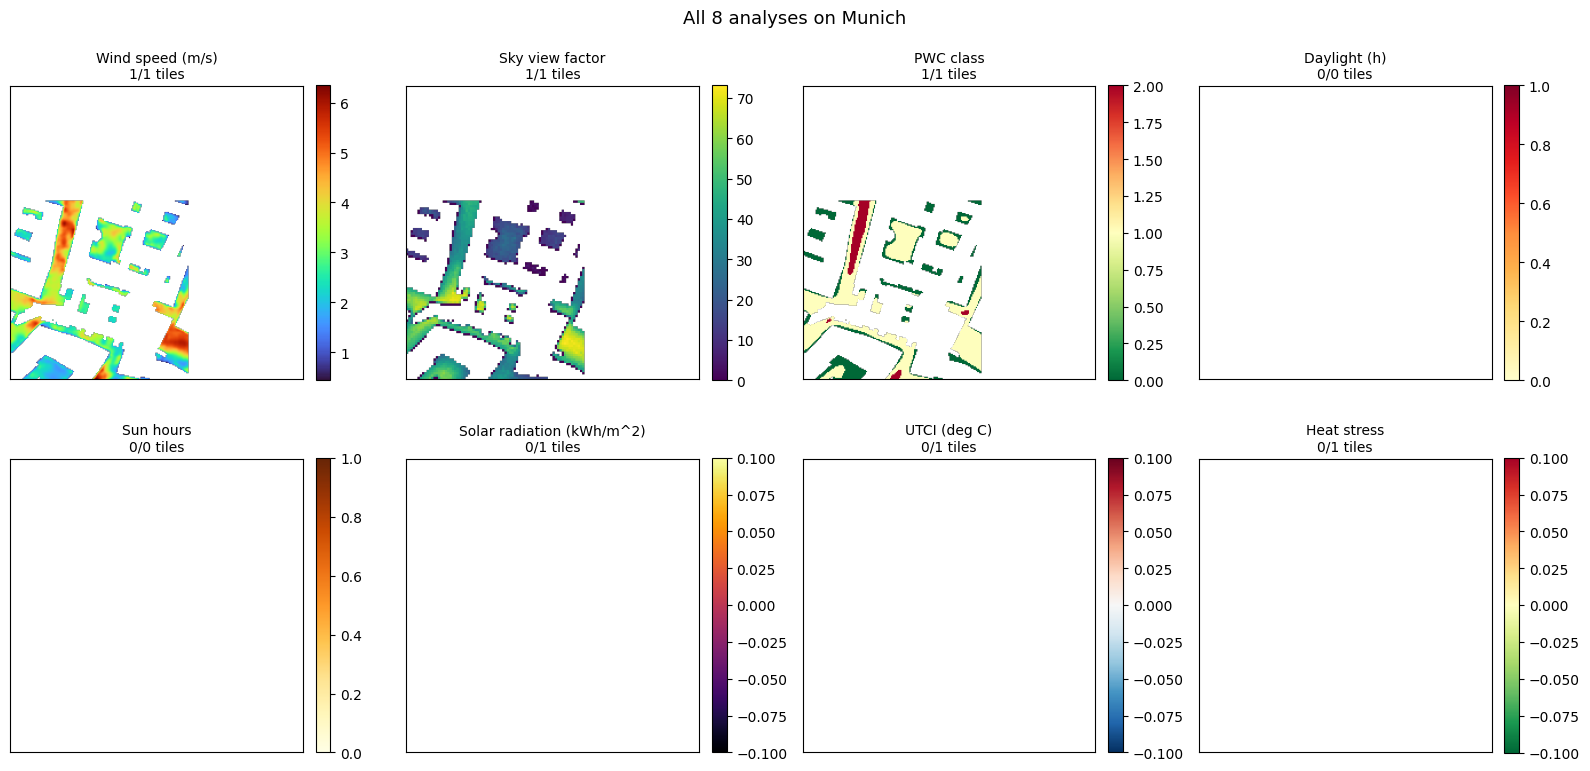

In [5]:
ORDER = [
    AnalysesName.wind_speed,
    AnalysesName.sky_view_factors,
    AnalysesName.pedestrian_wind_comfort,
    AnalysesName.daylight_availability,
    AnalysesName.direct_sun_hours,
    AnalysesName.solar_radiation,
    AnalysesName.thermal_comfort_index,
    AnalysesName.thermal_comfort_statistics,
]
LABELS = {
    AnalysesName.wind_speed: ("Wind speed (m/s)", "turbo"),
    AnalysesName.sky_view_factors: ("Sky view factor", "viridis"),
    AnalysesName.pedestrian_wind_comfort: ("PWC class", "RdYlGn_r"),
    AnalysesName.daylight_availability: ("Daylight (h)", "YlOrRd"),
    AnalysesName.direct_sun_hours: ("Sun hours", "YlOrBr"),
    AnalysesName.solar_radiation: ("Solar radiation (kWh/m^2)", "inferno"),
    AnalysesName.thermal_comfort_index: ("UTCI (deg C)", "RdBu_r"),
    AnalysesName.thermal_comfort_statistics: ("Heat stress", "RdYlGn_r"),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, atype in enumerate(ORDER):
    ax = axes.flat[i]
    r = results.get(atype)
    if r is None:
        ax.set_axis_off(); continue
    title, cmap = LABELS[atype]
    im = ax.imshow(np.flipud(r.merged_grid), cmap=cmap,
                   vmin=r.min_legend, vmax=r.max_legend)
    ax.set_title(f"{title}\n{r.succeeded_jobs}/{r.total_jobs} tiles", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f"All 8 analyses on {city.name}", fontsize=13)
plt.tight_layout(); plt.show()

## Print the per-analysis stats

In [6]:
for atype in ORDER:
    r = results.get(atype)
    if not r:
        print(f"{str(atype):35s}  (missing)")
        continue
    g = r.merged_grid
    valid = g[~np.isnan(g)]
    if valid.size == 0:
        print(f"{str(atype):35s}  shape={g.shape}  jobs={r.succeeded_jobs}/{r.total_jobs}  "
              f"(no valid cells)")
        continue
    print(f"{str(atype):35s}  shape={g.shape}  jobs={r.succeeded_jobs}/{r.total_jobs}  "
          f"min={float(valid.min()):7.2f}  median={float(np.median(valid)):7.2f}  "
          f"max={float(valid.max()):7.2f}")

wind-speed                           shape=(256, 256)  jobs=1/1  min=   0.44  median=   3.13  max=   6.34
sky-view-factors                     shape=(256, 256)  jobs=1/1  min=   0.00  median=  36.53  max=  73.06
pedestrian-wind-comfort              shape=(256, 256)  jobs=1/1  min=   0.00  median=   1.00  max=   2.00
daylight-availability                shape=(0, 0)  jobs=0/0  (no valid cells)
direct-sun-hours                     shape=(0, 0)  jobs=0/0  (no valid cells)
solar-radiation                      shape=(512, 512)  jobs=0/1  (no valid cells)
thermal-comfort-index                shape=(512, 512)  jobs=0/1  (no valid cells)
thermal-comfort-statistics           shape=(512, 512)  jobs=0/1  (no valid cells)


That's the full SDK analysis surface. Next: `06_image_rendering.ipynb`
covers PNG generation via the SDK itself (no plotly/matplotlib needed).